In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import itertools
from collections import Counter
from sklearn.cluster import SpectralClustering
from matplotlib.lines import Line2D
from scipy.sparse.csgraph import connected_components
import comorbidipy

pd.set_option('display.max_columns', 1000)

In [2]:
# OASIS file
oasis = pd.read_csv("data/oasis_v3.csv")

print(oasis.shape)

(3279386, 30)


In [3]:
oasis

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category
0,GGGGGGG999NDWze,2017-07-29,2BFLS,627,74,Female,0,0,0,0,0,1,RN,16,80027,CO,067181,Z47.89,E11.9,R41.82,I10.,Z79.84,NaN,0,0,0,1,0,22.860302,Normal weight
1,GGGGGGG999NGNUS,2017-01-23,2AGLS,168048,74,Female,0,0,0,0,0,1,RN,45,15136,PA,398069,Z48.89,R26.2,I10.,E11.9,E78.5,Z48.01,0,0,0,1,0,32.553070,Obese-Class1
2,GGGGGGG999XSUWN,2017-12-11,1CHKS,2192227,75,Male,0,0,0,0,0,1,RN,0,91784,CA,059583,M15.0,G20.,I11.0,I50.20,I35.0,I73.9,0,0,0,0,0,19.612240,Normal weight
3,GGGGGGG99D9D9XN,2017-11-15,1CFKV,233,70,Male,0,0,0,0,0,1,RN,28,83704,ID,137065,Z48.815,Z43.2,M62.81,I82.A11,E11.9,F31.9,0,0,0,1,0,19.129252,Normal weight
4,GGGGGGG99D9DDWU,2017-03-30,2CFKW,925,70,Male,0,0,0,0,0,1,RN,54,48767,MI,237165,E11.22,I13.2,I50.40,N18.6,E11.621,L97.529,1,1,1,1,0,30.128571,Obese-Class1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3279381,GGGGGGXzezWUUNG,2017-01-20,1CGKT,11748,59,Female,0,0,0,1,0,0,RN,69,78504,TX,677285,L02.31,L03.317,E11.65,I10.,E66.9,Z48.00,0,0,0,1,0,34.139898,Obese-Class1
3279382,GGGGGGXzzDSWXGW,2017-05-11,NaN,872,64,Male,0,0,0,0,0,1,RN,22,35554,AL,017872,I95.9,I10.,R55.,S02.2XXD,S01.21XD,E11.9,0,0,0,1,0,17.591139,Underweight
3279383,GGGGGGXzzXX9SzN,2017-10-25,1CGMS,455,64,Male,0,0,0,0,0,1,RN,19,40601,KY,187084,M62.81,R63.4,I48.91,I25.10,I73.9,Z86.73,0,0,0,1,0,19.663387,Normal weight
3279384,GGGGGGXzzXzS9ee,2017-06-05,1CGMS,1407,53,Male,0,0,0,0,0,1,PT,197,550141127,MN,247104,R26.2,M62.81,E11.319,E11.40,E11.22,I12.9,0,0,0,1,0,29.681929,Overweight


In [4]:
oasis.columns

Index(['Beneficiary_ID', 'Assessment_Effective_Date', 'Submitted_HIPPS_Code',
       'Facility_Internal_ID', 'Age', 'Gender',
       'American_Indian_or_Alaska_Native', 'Asian',
       'Black_or_African_American', 'Hispanic_or_Latino',
       'Native_Hawiian_or_Pacific_Islander', 'White', 'ByDiscipline',
       'Days_Cared_For', 'Patient_ZIP_Code', 'STATE_ID',
       'Agency_Medicare_Number', 'Primary_Diagnosis_ICD_10_C_M_Code',
       'Other_Diagnosis_Code_1_ICD_10_C_M',
       'Other_Diagnosis_Code_2_ICD_10_C_M',
       'Other_Diagnosis_Code_3_ICD_10_C_M',
       'Other_Diagnosis_Code_4_ICD_10_C_M',
       'Other_Diagnosis_Code_5_ICD_10_C_M', 'has_diabetes',
       'has_heart_failure', 'has_hypertension', 'ever_deceased',
       'ever_readmitted', 'BMI', 'BMI_Category'],
      dtype='object')

In [5]:
# Use the existing OASIS dataframe
df_icd = oasis.copy()

icdcols = [
    'Primary_Diagnosis_ICD_10_C_M_Code',
    'Other_Diagnosis_Code_1_ICD_10_C_M',
    'Other_Diagnosis_Code_2_ICD_10_C_M',
    'Other_Diagnosis_Code_3_ICD_10_C_M',
    'Other_Diagnosis_Code_4_ICD_10_C_M',
    'Other_Diagnosis_Code_5_ICD_10_C_M',
]


def clean_icd(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    if x in ("", "NAN", "NONE", "NULL"):
        return np.nan
    return x

for c in icdcols:
    df_icd[c] = df_icd[c].apply(clean_icd)

# Melt to long format: one ICD per row
df_melted = df_icd.melt(
    id_vars=["Beneficiary_ID", "Age"],
    value_vars=icdcols,
    var_name="DiagnosisType",
    value_name="ICDCode"
).dropna(subset=["ICDCode"]).drop_duplicates()

df_melted = df_melted.rename(columns={"Beneficiary_ID": "BENE_ID"})


In [6]:
df_charlson = comorbidipy.comorbidity(
    df_melted,
    id='BENE_ID',
    code='ICDCode',
    age='Age',
    score='charlson',
    icd='icd10',
    variant='quan',
    weighting='charlson',  # standard Charlson weighting
    assign0=True           # get 0 for absent comorbidities
)


In [7]:
# Van Walraven weights
df_elix_vw = comorbidipy.comorbidity(
    df_melted,
    id='BENE_ID',
    code='ICDCode',
    age='Age',
    score='elixhauser',
    icd='icd10',
    variant='quan',
    weighting='vw',      # Van Walraven
    assign0=True
)

# Swiss weights (optional)
df_elix_swiss = comorbidipy.comorbidity(
    df_melted,
    id='BENE_ID',
    code='ICDCode',
    age='Age',
    score='elixhauser',
    icd='icd10',
    variant='quan',
    weighting='swiss',   # Swiss weights
    assign0=True
)

In [8]:
# Charlson
df_charlson = df_charlson.rename(columns={
    'comorbidity_score': 'charlson_score',
    'age_adj_comorbidity_score': 'charlson_ageadj',
    'survival_10yr': 'charlson_survival_10yr'
})

# Elixhauser Quan
df_elix_vw = df_elix_vw.rename(columns={
    'comorbidity_score': 'elix_quan_score',
    'age_adj_comorbidity_score': 'elix_quan_ageadj'
})

# Elixhauser Swiss
df_elix_swiss = df_elix_swiss.rename(columns={
    'comorbidity_score': 'elix_swiss_score',
    'age_adj_comorbidity_score': 'elix_swiss_ageadj'
})

print('Charlson: ', df_charlson.columns)
print('Elix-quan: ', df_elix_vw.columns)
print('Elix-swiss: ', df_elix_swiss.columns)

Charlson:  Index(['BENE_ID', 'Age', 'aids', 'ami', 'canc', 'cevd', 'chf', 'copd',
       'dementia', 'hp', 'metacanc', 'mld', 'pud', 'pvd', 'rend', 'rheumd',
       'diab', 'diabwc', 'msld', 'charlson_score', 'charlson_ageadj',
       'charlson_survival_10yr'],
      dtype='object')
Elix-quan:  Index(['BENE_ID', 'Age', 'aids', 'alcohol', 'carit', 'chf', 'coag', 'cpd',
       'dane', 'depre', 'drug', 'fed', 'hypc', 'hypothy', 'hypunc', 'ld',
       'lymph', 'metacanc', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pvd',
       'rf', 'rheumd', 'solidtum', 'valv', 'wloss', 'blane', 'diabc',
       'diabunc', 'pud', 'elix_quan_score', 'elix_quan_ageadj'],
      dtype='object')
Elix-swiss:  Index(['BENE_ID', 'Age', 'aids', 'alcohol', 'carit', 'chf', 'coag', 'cpd',
       'dane', 'depre', 'drug', 'fed', 'hypc', 'hypothy', 'hypunc', 'ld',
       'lymph', 'metacanc', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pvd',
       'rf', 'rheumd', 'solidtum', 'valv', 'wloss', 'blane', 'diabc',
       'diabunc'

In [9]:
keep_id_age = ['BENE_ID', 'Age']
score_cols_char  = ['charlson_score', 'charlson_ageadj', 'charlson_survival_10yr']
score_cols_elixq = ['elix_quan_score', 'elix_quan_ageadj']
score_cols_elixs = ['elix_swiss_score', 'elix_swiss_ageadj']

# 1. Identify condition columns per scoring, excluding ID/age and summary scores
cond_char  = [c for c in df_charlson.columns
              if c not in keep_id_age + score_cols_char]
cond_elixq = [c for c in df_elix_vw.columns
              if c not in keep_id_age + score_cols_elixq]
cond_elixs = [c for c in df_elix_swiss.columns
              if c not in keep_id_age + score_cols_elixs]

# 2. Unified condition list (no suffixes, ignoring method)
all_cond_names = sorted(set(cond_char) | set(cond_elixq) | set(cond_elixs))

# 3. Rename condition columns with score-specific suffixes
char_ren  = df_charlson.rename(columns={c: f"{c}_char"   for c in cond_char})
elixq_ren = df_elix_vw.rename(columns={c: f"{c}_elixq"  for c in cond_elixq})
elixs_ren = df_elix_swiss.rename(columns={c: f"{c}_elixs" for c in cond_elixs})

# 4. Merge the three dataframes on BENE_ID + Age
df_merged = (
    char_ren
    .merge(elixq_ren, on=keep_id_age, how='outer')
    .merge(elixs_ren, on=keep_id_age, how='outer')
)

# 5. Build all unified condition columns in a separate dict, then concat once

unified_cond = {}  # key: condition name, value: Series of 0/1 ints

for cond in all_cond_names:
    cols_for_cond = []
    c_char  = f"{cond}_char"
    c_elixq = f"{cond}_elixq"
    c_elixs = f"{cond}_elixs"

    if c_char in df_merged.columns:
        cols_for_cond.append(c_char)
    if c_elixq in df_merged.columns:
        cols_for_cond.append(c_elixq)
    if c_elixs in df_merged.columns:
        cols_for_cond.append(c_elixs)

    if not cols_for_cond:
        continue

    # Extract per-method columns for this condition
    tmp = df_merged[cols_for_cond].fillna(0).astype(float)

    # Row-wise mean as proxy for majority vote among {0,1}
    mean_vals = tmp.mean(axis=1)

    # Most-used value: 1 if majority of methods say 1, else 0
    # (ties at 0.5 are treated as 1 if any method has 1; change if you prefer)
    unified_cond[cond] = (
        (mean_vals > 0.5) |
        (mean_vals.eq(0.5) & mean_vals.gt(0))
    ).astype(int)

# 6. Create a unified condition DataFrame and join it once to df_merged

cond_df = pd.DataFrame(unified_cond, index=df_merged.index)
df_merged = pd.concat([df_merged, cond_df], axis=1)

# 7. Optionally drop the per-method condition columns, keeping only unified ones
per_method_cols = [c for c in df_merged.columns
                   if c.endswith('_char') or c.endswith('_elixq') or c.endswith('_elixs')]
df_merged = df_merged.drop(columns=per_method_cols)
df_merged

,BENE_ID,Age,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,cpd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,mld,msld,obes,ond,para,pcd,psycho,pud,pvd,rend,rf,rheumd,solidtum,valv,wloss
0,GGGGGGG99999D9N,84,1.0,5.0,2.136432e-01,3.0,7.0,0.0,4.0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GGGGGGG99999GUN,67,2.0,4.0,5.339147e-01,4.0,6.0,7.0,9.0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,GGGGGGG99999GeU,74,1.0,4.0,5.339147e-01,7.0,10.0,10.0,13.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,GGGGGGG99999SSG,75,0.0,3.0,7.748156e-01,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,GGGGGGG99999XUX,74,4.0,7.0,8.807547e-05,2.0,5.0,2.0,5.0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3279381,GGGGGGXzzzzUzD9,62,2.0,4.0,5.339147e-01,11.0,13.0,18.0,20.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0
3279382,GGGGGGXzzzzX9eX,41,1.0,1.0,9.587042e-01,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3279383,GGGGGGXzzzzXXeU,23,0.0,0.0,9.830000e-01,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3279384,GGGGGGXzzzzeDN9,38,1.0,1.0,9.587042e-01,3.0,3.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
df_merged.columns

Index(['BENE_ID', 'Age', 'charlson_score', 'charlson_ageadj',
       'charlson_survival_10yr', 'elix_quan_score', 'elix_quan_ageadj',
       'elix_swiss_score', 'elix_swiss_ageadj', 'aids', 'alcohol', 'ami',
       'blane', 'canc', 'carit', 'cevd', 'chf', 'coag', 'copd', 'cpd', 'dane',
       'dementia', 'depre', 'diab', 'diabc', 'diabunc', 'diabwc', 'drug',
       'fed', 'hp', 'hypc', 'hypothy', 'hypunc', 'ld', 'lymph', 'metacanc',
       'mld', 'msld', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pud', 'pvd',
       'rend', 'rf', 'rheumd', 'solidtum', 'valv', 'wloss'],
      dtype='object')

In [11]:
# 1. Select the comorbidity / merged columns of interest
cols = [
    'aids', 'alcohol', 'ami',
       'blane', 'canc', 'carit', 'cevd', 'chf', 'coag', 'copd', 'cpd', 'dane',
       'dementia', 'depre', 'diab', 'diabc', 'diabunc', 'diabwc', 'drug',
       'fed', 'hp', 'hypc', 'hypothy', 'hypunc', 'ld', 'lymph', 'metacanc',
       'mld', 'msld', 'obes', 'ond', 'para', 'pcd', 'psycho', 'pud', 'pvd',
       'rend', 'rf', 'rheumd', 'solidtum', 'valv', 'wloss']

X = df_merged[cols].copy()

# 2. Compute absolute correlation matrix (Pearson by default)
corr_matrix = X.corr().abs()  

# 3. Take the upper triangle of the correlation matrix to avoid double-counting pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Choose a threshold and find columns to drop
threshold = 0.70  

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

print("Highly correlated columns to drop:", to_drop)

# 5. Drop them from your full dataframe
df_reduced = df_merged.drop(columns=to_drop)

Highly correlated columns to drop: ['cpd', 'mld', 'para', 'rf', 'solidtum']


In [12]:
df_reduced = df_reduced.rename(columns={"BENE_ID": "Beneficiary_ID"})

dfWrisk = oasis.merge(
    df_reduced,
    on=['Beneficiary_ID', 'Age'],
    how='left'
)

dfWrisk

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,Primary_Diagnosis_ICD_10_C_M_Code,Other_Diagnosis_Code_1_ICD_10_C_M,Other_Diagnosis_Code_2_ICD_10_C_M,Other_Diagnosis_Code_3_ICD_10_C_M,Other_Diagnosis_Code_4_ICD_10_C_M,Other_Diagnosis_Code_5_ICD_10_C_M,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss
0,GGGGGGG999NDWze,2017-07-29,2BFLS,627,74,Female,0,0,0,0,0,1,RN,16,80027,CO,067181,Z47.89,E11.9,R41.82,I10.,Z79.84,NaN,0,0,0,1,0,22.860302,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GGGGGGG999NGNUS,2017-01-23,2AGLS,168048,74,Female,0,0,0,0,0,1,RN,45,15136,PA,398069,Z48.89,R26.2,I10.,E11.9,E78.5,Z48.01,0,0,0,1,0,32.553070,Obese-Class1,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GGGGGGG999XSUWN,2017-12-11,1CHKS,2192227,75,Male,0,0,0,0,0,1,RN,0,91784,CA,059583,M15.0,G20.,I11.0,I50.20,I35.0,I73.9,0,0,0,0,0,19.612240,Normal weight,1.0,4.0,0.533915,12.0,15.0,19.0,22.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,GGGGGGG99D9D9XN,2017-11-15,1CFKV,233,70,Male,0,0,0,0,0,1,RN,28,83704,ID,137065,Z48.815,Z43.2,M62.81,I82.A11,E11.9,F31.9,0,0,0,1,0,19.129252,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,GGGGGGG99D9DDWU,2017-03-30,2CFKW,925,70,Male,0,0,0,0,0,1,RN,54,48767,MI,237165,E11.22,I13.2,I50.40,N18.6,E11.621,L97.529,1,1,1,1,0,30.128571,Obese-Class1,3.0,6.0,0.022454,12.0,15.0,18.0,21.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3279381,GGGGGGXzezWUUNG,2017-01-20,1CGKT,11748,59,Female,0,0,0,1,0,0,RN,69,78504,TX,677285,L02.31,L03.317,E11.65,I10.,E66.9,Z48.00,0,0,0,1,0,34.139898,Obese-Class1,0.0,1.0,0.958704,0.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3279382,GGGGGGXzzDSWXGW,2017-05-11,NaN,872,64,Male,0,0,0,0,0,1,RN,22,35554,AL,017872,I95.9,I10.,R55.,S02.2XXD,S01.21XD,E11.9,0,0,0,1,0,17.591139,Underweight,0.0,2.0,0.901470,0.0,2.0,0.0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3279383,GGGGGGXzzXX9SzN,2017-10-25,1CGMS,455,64,Male,0,0,0,0,0,1,RN,19,40601,KY,187084,M62.81,R63.4,I48.91,I25.10,I73.9,Z86.73,0,0,0,1,0,19.663387,Normal weight,0.0,2.0,0.901470,5.0,7.0,6.0,8.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3279384,GGGGGGXzzXzS9ee,2017-06-05,1CGMS,1407,53,Male,0,0,0,0,0,1,PT,197,550141127,MN,247104,R26.2,M62.81,E11.319,E11.40,E11.22,I12.9,0,0,0,1,0,29.681929,Overweight,0.0,1.0,0.958704,0.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
dfWrisk.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'Patient_ZIP_Code',
 'STATE_ID',
 'Agency_Medicare_Number',
 'Primary_Diagnosis_ICD_10_C_M_Code',
 'Other_Diagnosis_Code_1_ICD_10_C_M',
 'Other_Diagnosis_Code_2_ICD_10_C_M',
 'Other_Diagnosis_Code_3_ICD_10_C_M',
 'Other_Diagnosis_Code_4_ICD_10_C_M',
 'Other_Diagnosis_Code_5_ICD_10_C_M',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension',
 'ever_deceased',
 'ever_readmitted',
 'BMI',
 'BMI_Category',
 'charlson_score',
 'charlson_ageadj',
 'charlson_survival_10yr',
 'elix_quan_score',
 'elix_quan_ageadj',
 'elix_swiss_score',
 'elix_swiss_ageadj',
 'aids',
 'alcohol',
 'ami',
 'blane',
 'canc',
 'carit',
 'cevd',
 'chf',
 'coag',
 'copd',
 'dane',
 'dementia',
 'depre',
 'diab',
 

In [14]:
beneficiary_col = 'Beneficiary_ID'

MIN_CODE_FREQ = 20
SIMILARITY = 'jaccard'
EDGE_THRESHOLD = 0.05
N_CLUSTERS = 50
RANDOM_STATE = 42
TOP_NODES_TO_DRAW = 150
TOP_LABELS_TO_DRAW = 40
MAX_LEGEND_ITEMS = 15

def icd_family_from_code(code: str) -> str:
    if pd.isna(code) or not isinstance(code, str) or len(code) == 0:
        return "Other"
    c = code.upper().strip()

    if c.startswith(("I",)):
        return "Circulatory"
    if c.startswith(("E",)):
        return "Endocrine/Metabolic"
    if c.startswith(("J",)):
        return "Respiratory"
    if c.startswith(("N",)):
        return "Genitourinary"
    if c.startswith(("F",)):
        return "Mental/Behavioral"
    if c.startswith(("G",)):
        return "Neurologic"
    if c.startswith(("M",)):
        return "Musculoskeletal"
    if c.startswith(("K",)):
        return "Digestive"
    if c.startswith(("C", "D0", "D1", "D2", "D3", "D4")):
        return "Neoplasm/Hematologic"
    if c.startswith(("R",)):
        return "Symptoms/Signs"
    if c.startswith(("L",)):
        return "Skin/Subcutaneous"
    if c.startswith(("H",)):
        return "Eye/Ear"
    if c.startswith(("A", "B")):
        return "Infectious"
    if c.startswith(("S", "T")):
        return "Injury/Toxicity"
    if c.startswith(("Z",)):
        return "Factors Influencing Health Status"
    return "Other"

# =========================
# STEP 1: CLEAN ICD CODES
# =========================
work = dfWrisk.copy()

for c in icdcols:
    work[c] = work[c].apply(clean_icd)

# patient -> set of ICD codes
patient_codes = (
    work.groupby(beneficiary_col)[icdcols]
    .apply(lambda g: set(v for v in pd.unique(g.values.ravel()) if pd.notna(v)))
    .to_dict()
)


In [15]:
# =========================
# STEP 2: FILTER RARE CODES
# =========================
code_freq = Counter()
for codes in patient_codes.values():
    code_freq.update(codes)

kept_codes = {code for code, cnt in code_freq.items() if cnt >= MIN_CODE_FREQ}

patient_codes = {
    pid: {c for c in codes if c in kept_codes}
    for pid, codes in patient_codes.items()
}
patient_codes = {pid: codes for pid, codes in patient_codes.items() if len(codes) > 0}

all_codes = sorted({c for codes in patient_codes.values() for c in codes})
code_to_idx = {c: i for i, c in enumerate(all_codes)}
n_codes = len(all_codes)

# =========================
# STEP 3: BUILD CO-OCCURRENCE GRAPH
# =========================
co_counts = np.zeros((n_codes, n_codes), dtype=np.float32)
code_counts = np.zeros(n_codes, dtype=np.float32)

for codes in patient_codes.values():
    idxs = sorted({code_to_idx[c] for c in codes})
    for i in idxs:
        code_counts[i] += 1
    for i, j in itertools.combinations(idxs, 2):
        co_counts[i, j] += 1
        co_counts[j, i] += 1



In [16]:
# =========================
# STEP 4: BUILD AFFINITY MATRIX
# =========================
affinity = np.zeros((n_codes, n_codes), dtype=np.float32)

if SIMILARITY == 'jaccard':
    for i in range(n_codes):
        for j in range(i + 1, n_codes):
            inter = co_counts[i, j]
            if inter == 0:
                continue
            union = code_counts[i] + code_counts[j] - inter
            if union <= 0:
                continue
            sim = inter / union
            if sim >= EDGE_THRESHOLD:
                affinity[i, j] = sim
                affinity[j, i] = sim

elif SIMILARITY == 'cosine':
    for i in range(n_codes):
        for j in range(i + 1, n_codes):
            inter = co_counts[i, j]
            if inter == 0:
                continue
            denom = np.sqrt(code_counts[i] * code_counts[j])
            if denom <= 0:
                continue
            sim = inter / denom
            if sim >= EDGE_THRESHOLD:
                affinity[i, j] = sim
                affinity[j, i] = sim
else:
    raise ValueError("SIMILARITY must be 'jaccard' or 'cosine'")

np.fill_diagonal(affinity, 1.0)

In [17]:
# =========================
# STEP 5: SPECTRAL CLUSTERING
# =========================
non_isolated_mask = affinity.sum(axis=1) > 1.0
affinity_sc = affinity[np.ix_(non_isolated_mask, non_isolated_mask)]
codes_sc = [code for code, keep in zip(all_codes, non_isolated_mask) if keep]

if affinity_sc.shape[0] == 0:
    raise ValueError("No connected ICD graph remains after thresholding. Lower EDGE_THRESHOLD.")

n_components, component_labels = connected_components(
    affinity_sc, directed=False, connection='weak'
)

component_sizes = pd.Series(component_labels).value_counts()
largest_component = component_sizes.index[0]
largest_mask = component_labels == largest_component

affinity_main = affinity_sc[np.ix_(largest_mask, largest_mask)]
codes_main = [code for code, keep in zip(codes_sc, largest_mask) if keep]

if affinity_main.shape[0] < 2:
    raise ValueError("Largest connected component is too small to cluster.")

n_clusters_main = min(N_CLUSTERS, max(2, affinity_main.shape[0] // 2))

sc = SpectralClustering(
    n_clusters=n_clusters_main,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=RANDOM_STATE,
    eigen_solver='arpack'
)

labels_main = sc.fit_predict(affinity_main)

code_cluster_df = pd.DataFrame({
    'ICD_Code': codes_main,
    'ICD_Cluster': labels_main,
    'Code_Frequency': [code_freq[c] for c in codes_main]
})

other_codes = [code for code, keep in zip(codes_sc, ~largest_mask) if keep]
other_component_labels = [lab for lab, keep in zip(component_labels, ~largest_mask) if keep]

if other_codes:
    other_df = pd.DataFrame({
        'ICD_Code': other_codes,
        'ICD_Cluster': [-(lab + 2) for lab in other_component_labels],
        'Code_Frequency': [code_freq[c] for c in other_codes]
    })
    code_cluster_df = pd.concat([code_cluster_df, other_df], ignore_index=True)

isolated_codes = [code for code, keep in zip(all_codes, non_isolated_mask) if not keep]
if isolated_codes:
    isolated_df = pd.DataFrame({
        'ICD_Code': isolated_codes,
        'ICD_Cluster': -1,
        'Code_Frequency': [code_freq[c] for c in isolated_codes]
    })
    code_cluster_df = pd.concat([code_cluster_df, isolated_df], ignore_index=True)


In [18]:
# =========================
# STEP 6: NAME THE CLUSTERS
# =========================
cluster_name_map = {-1: "Isolated / Unclustered"}

tmp = code_cluster_df[code_cluster_df['ICD_Cluster'] != -1].copy()
tmp['ICD_Family'] = tmp['ICD_Code'].apply(icd_family_from_code)

for cl, grp in tmp.groupby('ICD_Cluster'):
    grp = grp.sort_values('Code_Frequency', ascending=False)
    family = grp['ICD_Family'].mode().iloc[0] if not grp['ICD_Family'].mode().empty else "Mixed"
    top_codes = grp['ICD_Code'].head(2).tolist()

    if len(top_codes) >= 2:
        cluster_name_map[cl] = f"{family}: {top_codes[0]}, {top_codes[1]}"
    elif len(top_codes) == 1:
        cluster_name_map[cl] = f"{family}: {top_codes[0]}"
    else:
        cluster_name_map[cl] = f"{family} cluster"

code_cluster_df['ICD_Cluster_Name'] = code_cluster_df['ICD_Cluster'].map(cluster_name_map)

code_to_cluster = dict(zip(code_cluster_df['ICD_Code'], code_cluster_df['ICD_Cluster']))
code_to_cluster_name = dict(zip(code_cluster_df['ICD_Code'], code_cluster_df['ICD_Cluster_Name']))

print("Connected components in filtered graph:", n_components)
print("Largest component size:", affinity_main.shape[0])
print("Codes in small components:", len(other_codes))
print("Isolated codes:", len(isolated_codes))

# =========================
# STEP 7: BUILD NETWORK GRAPH
# =========================
G = nx.Graph()

for _, row in code_cluster_df.iterrows():
    G.add_node(
        row['ICD_Code'],
        cluster=int(row['ICD_Cluster']),
        cluster_name=row['ICD_Cluster_Name'],
        frequency=int(row['Code_Frequency'])
    )

for i in range(n_codes):
    for j in range(i + 1, n_codes):
        w = affinity[i, j]
        if w > 0:
            G.add_edge(all_codes[i], all_codes[j], weight=float(w))

top_nodes = (
    code_cluster_df[code_cluster_df['ICD_Cluster'] != -1]
    .sort_values('Code_Frequency', ascending=False)
    .head(TOP_NODES_TO_DRAW)['ICD_Code']
    .tolist()
)

H = G.subgraph(top_nodes).copy()
isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

if H.number_of_nodes() == 0:
    raise ValueError("Visualization subgraph is empty. Lower EDGE_THRESHOLD or TOP_NODES_TO_DRAW filter.")

Connected components in filtered graph: 659
Largest component size: 65
Codes in small components: 1628
Isolated codes: 7779


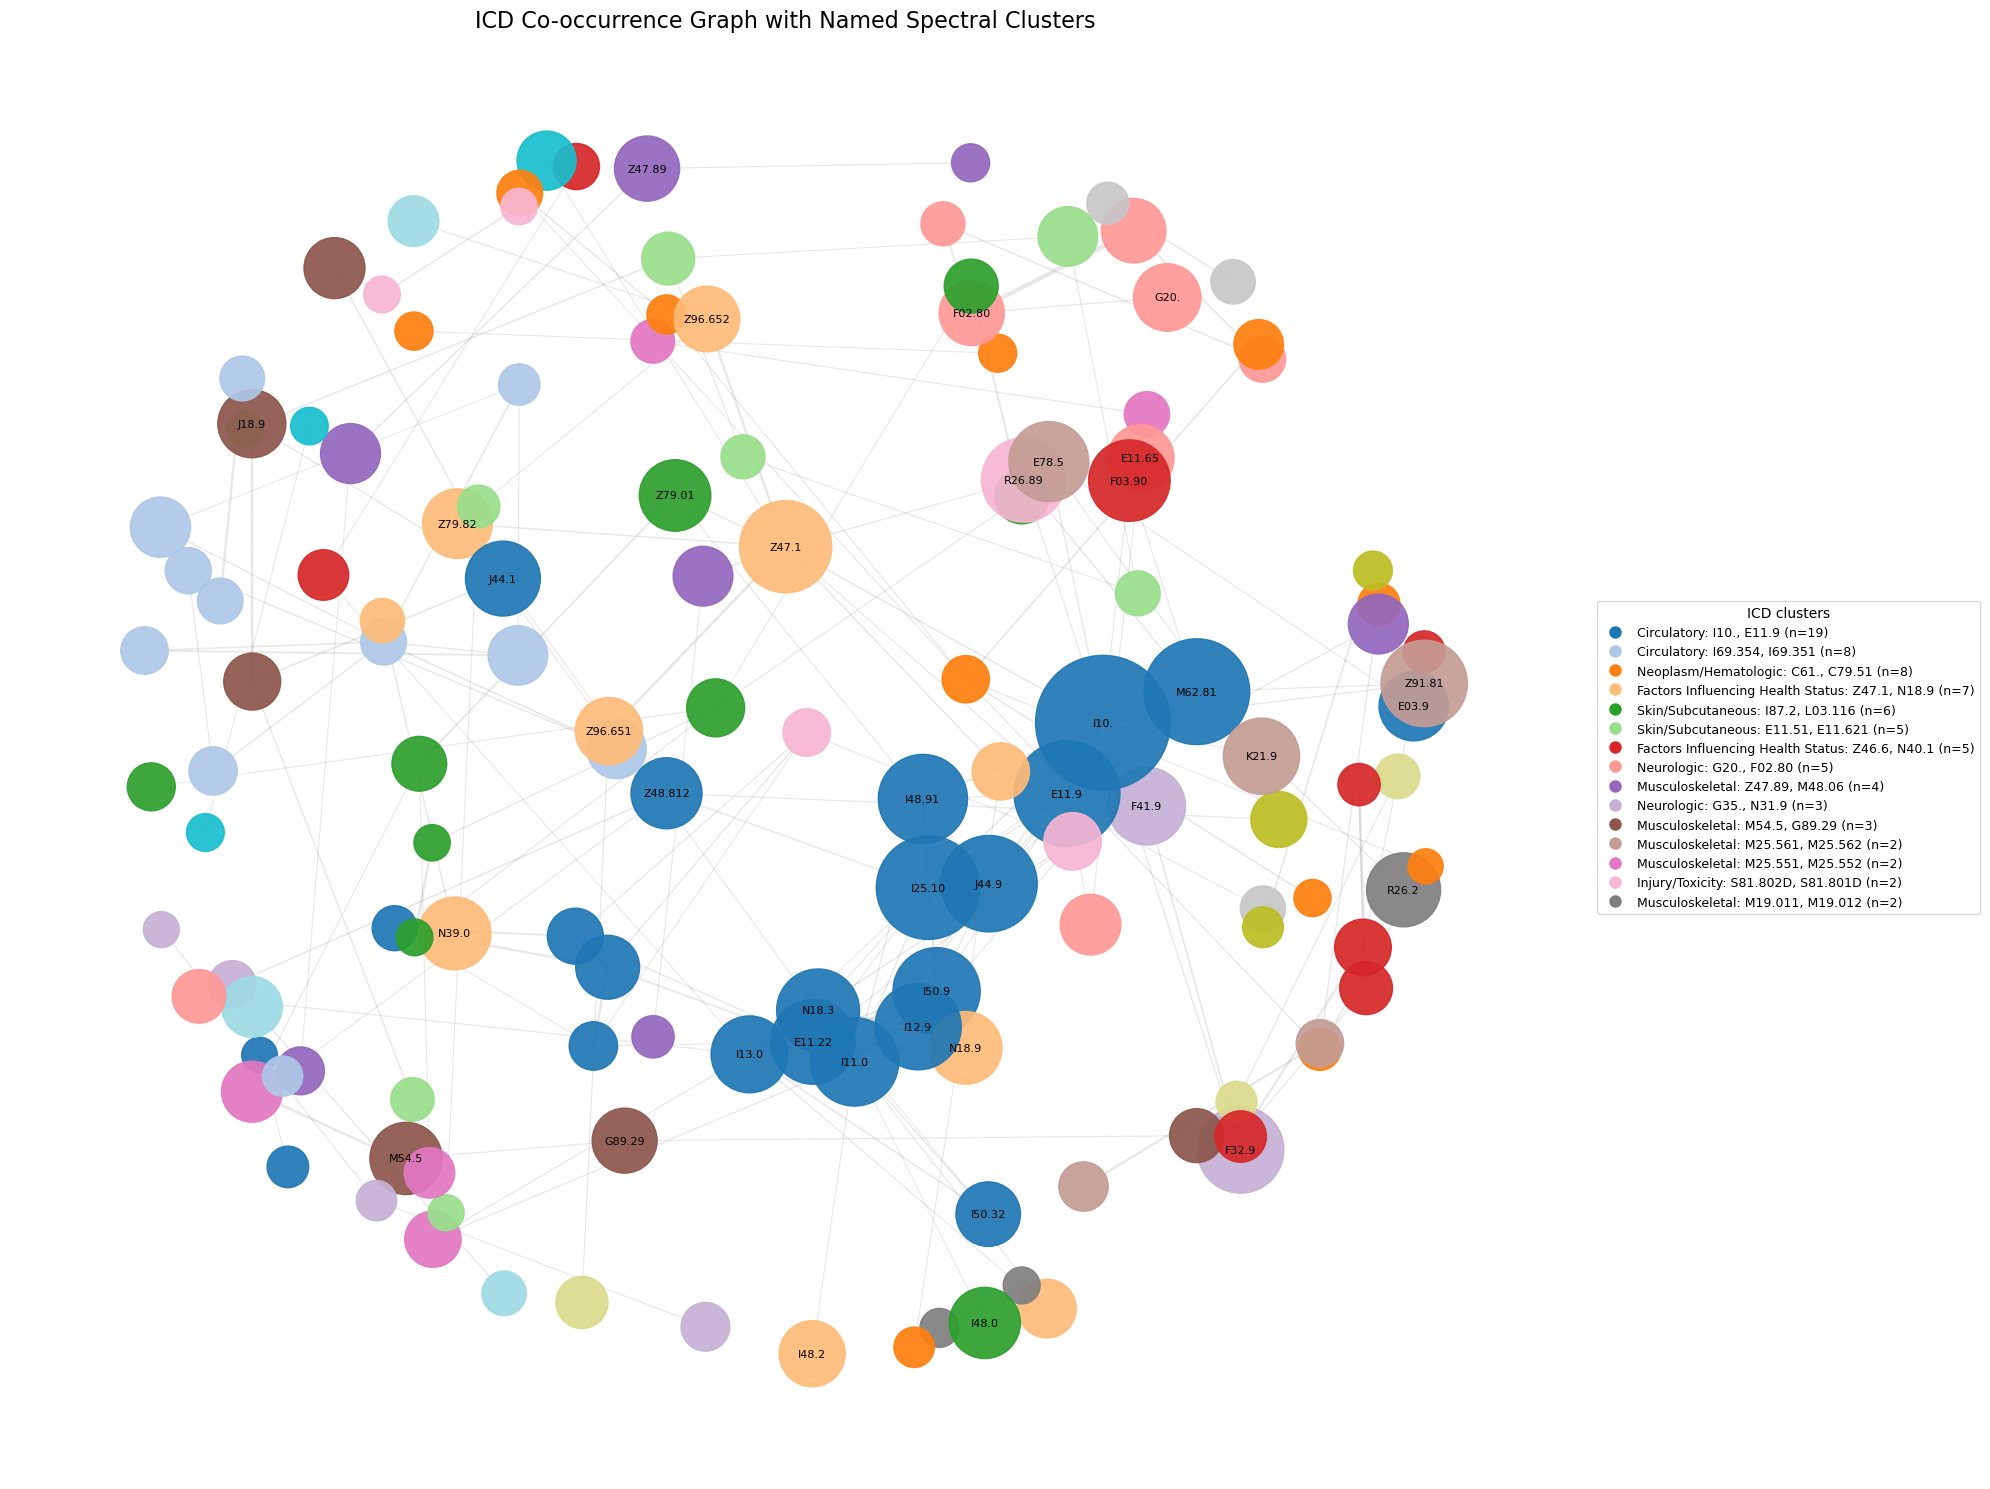

Nodes in full graph: 9472
Edges in full graph: 1186
Nodes drawn: 139
Edges drawn: 179


In [19]:
# =========================
# STEP 8: DRAW GRAPH WITH NAMED LEGEND
# =========================
displayed_nodes_df = code_cluster_df[
    code_cluster_df['ICD_Code'].isin(H.nodes())
].copy()

displayed_nodes_df = displayed_nodes_df[displayed_nodes_df['ICD_Cluster'] != -1]

cluster_counts = (
    displayed_nodes_df
    .groupby('ICD_Cluster', as_index=True)['ICD_Code']
    .count()
    .sort_values(ascending=False)
)

cluster_ids = cluster_counts.index.tolist()
cmap = plt.colormaps['tab20']
cluster_to_color = {cl: cmap(i % 20) for i, cl in enumerate(cluster_ids)}
default_color = 'lightgray'

node_colors = [
    cluster_to_color.get(H.nodes[n]['cluster'], default_color)
    for n in H.nodes()
]
node_sizes = [20 + 8 * np.sqrt(H.nodes[n]['frequency']) for n in H.nodes()]
edge_widths = [0.5 + 6 * H[u][v]['weight'] for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(20, 15))
pos = nx.spring_layout(H, k=0.45, seed=RANDOM_STATE, weight='weight', iterations=100)

nx.draw_networkx_edges(
    H, pos,
    alpha=0.18,
    width=edge_widths,
    edge_color='gray',
    ax=ax
)

nx.draw_networkx_nodes(
    H, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.92,
    ax=ax
)

label_nodes = (
    displayed_nodes_df
    .sort_values('Code_Frequency', ascending=False)
    .head(TOP_LABELS_TO_DRAW)['ICD_Code']
    .tolist()
)

nx.draw_networkx_labels(
    H, pos,
    labels={n: n for n in label_nodes if n in H.nodes()},
    font_size=8,
    ax=ax
)

cluster_name_lookup = (
    displayed_nodes_df
    .drop_duplicates('ICD_Cluster')
    .set_index('ICD_Cluster')['ICD_Cluster_Name']
    .to_dict()
)

legend_handles = []
for cl, count in cluster_counts.items():
    color = cluster_to_color.get(cl, default_color)
    label = cluster_name_lookup.get(cl, f'Cluster {cl}')
    handle = Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'{label} (n={count})',
        markerfacecolor=color,
        markersize=10
    )
    legend_handles.append(handle)

legend_handles = legend_handles[:MAX_LEGEND_ITEMS]

if legend_handles:
    ax.legend(
        handles=legend_handles,
        title='ICD clusters',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

ax.set_title("ICD Co-occurrence Graph with Named Spectral Clusters", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()\

print("Nodes in full graph:", G.number_of_nodes())
print("Edges in full graph:", G.number_of_edges())
print("Nodes drawn:", H.number_of_nodes())
print("Edges drawn:", H.number_of_edges())

In [20]:
top_codes_per_cluster = (
    code_cluster_df[code_cluster_df['ICD_Cluster'] != -1]
    .sort_values(['ICD_Cluster', 'Code_Frequency'], ascending=[True, False])
    .groupby(['ICD_Cluster', 'ICD_Cluster_Name'])
    .head(15)
    .reset_index(drop=True)
)

cluster_summary = (
    top_codes_per_cluster
    .groupby(['ICD_Cluster', 'ICD_Cluster_Name'])
    .agg(
        Num_Codes=('ICD_Code', 'count'),
        Total_Code_Frequency=('Code_Frequency', 'sum'),
        Top_Codes=('ICD_Code', lambda s: ", ".join(s.head(5)))
    )
    .reset_index()
    .sort_values('Total_Code_Frequency', ascending=False)
)

cluster_summary

,ICD_Cluster,ICD_Cluster_Name,Num_Codes,Total_Code_Frequency,Top_Codes
672,14,"Circulatory: I10., E11.9",15,5116328,"I10., E11.9, M62.81, I25.10, J44.9"
659,1,"Factors Influencing Health Status: Z47.1, N18.9",7,768400,"Z47.1, N18.9, Z79.82, Z96.651, Z96.652"
679,21,"Mental/Behavioral: F32.9, F41.9",2,388247,"F32.9, F41.9"
689,31,"Digestive: E78.5, K21.9",2,310127,"E78.5, K21.9"
610,-50,"Neurologic: G20., F02.80",5,264531,"G20., F02.80, G30.9, F02.81, G30.1"
...,...,...,...,...,...
158,-502,"Injury/Toxicity: S62.327D, S62.325D",2,42,"S62.327D, S62.325D"
96,-564,"Injury/Toxicity: S82.261D, S82.461D",2,42,"S82.261D, S82.461D"
82,-578,"Injury/Toxicity: S90.425A, S90.422A",2,42,"S90.425A, S90.422A"
66,-594,"Injury/Toxicity: S92.001S, S92.002S",2,41,"S92.001S, S92.002S"


In [21]:
# =========================
# STEP 9: MAP BACK TO ORIGINAL DF
# =========================
for c in icdcols:
    work[c + '_Cluster'] = work[c].map(code_to_cluster).fillna(-1).astype(int)
    work[c + '_Cluster_Name'] = work[c].map(code_to_cluster_name).fillna("Isolated / Unclustered")

# optional row-level summaries
cluster_cols = [c + '_Cluster' for c in icdcols]
cluster_name_cols = [c + '_Cluster_Name' for c in icdcols]

def row_clusters(row):
    vals = []
    for c in cluster_cols:
        v = row[c]
        if pd.notna(v) and int(v) != -1:
            vals.append(int(v))
    return sorted(set(vals))

def row_cluster_names(row):
    vals = []
    for c in cluster_name_cols:
        v = row[c]
        if pd.notna(v) and v != "Isolated / Unclustered":
            vals.append(v)
    return sorted(set(vals))

work['ICD_Clusters_In_Row'] = work.apply(row_clusters, axis=1)
work['ICD_Cluster_Names_In_Row'] = work.apply(row_cluster_names, axis=1)

# optional: if you want to drop raw ICD columns after mapping
work_no_raw_icd = work.drop(columns=icdcols)
work_no_raw_icd

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Patient_ZIP_Code,STATE_ID,Agency_Medicare_Number,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss,Primary_Diagnosis_ICD_10_C_M_Code_Cluster,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_Name,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster_Name,ICD_Clusters_In_Row,ICD_Cluster_Names_In_Row
0,GGGGGGG999NDWze,2017-07-29,2BFLS,627,74,Female,0,0,0,0,0,1,RN,16,80027,CO,067181,0,0,0,1,0,22.860302,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-283,"Musculoskeletal: Z47.89, M48.06",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,14,"Circulatory: I10., E11.9",19,Factors Influencing Health Status: Z79.84,-1,Isolated / Unclustered,"[-283, 14, 19]","[Circulatory: I10., E11.9, Factors Influencing..."
1,GGGGGGG999NGNUS,2017-01-23,2AGLS,168048,74,Female,0,0,0,0,0,1,RN,45,15136,PA,398069,0,0,0,1,0,32.553070,Obese-Class1,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,Isolated / Unclustered,6,Symptoms/Signs: R26.2,14,"Circulatory: I10., E11.9",14,"Circulatory: I10., E11.9",31,"Digestive: E78.5, K21.9",13,Factors Influencing Health Status: Z48.01,"[6, 13, 14, 31]","[Circulatory: I10., E11.9, Digestive: E78.5, K..."
2,GGGGGGG999XSUWN,2017-12-11,1CHKS,2192227,75,Male,0,0,0,0,0,1,RN,0,91784,CA,059583,0,0,0,0,0,19.612240,Normal weight,1.0,4.0,0.533915,12.0,15.0,19.0,22.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,-1,Isolated / Unclustered,-50,"Neurologic: G20., F02.80",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,-1,Isolated / Unclustered,-1,Isolated / Unclustered,"[-50, 14]","[Circulatory: I10., E11.9, Neurologic: G20., F..."
3,GGGGGGG99D9D9XN,2017-11-15,1CFKV,233,70,Male,0,0,0,0,0,1,RN,28,83704,ID,137065,0,0,0,1,0,19.129252,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-9,"Factors Influencing Health Status: Z48.815, Z43.3",-9,"Factors Influencing Health Status: Z48.815, Z43.3",14,"Circulatory: I10., E11.9",-90,"Circulatory: I82.A11, I82.B11",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,"[-90, -9, 14]","[Circulatory: I10., E11.9, Circulatory: I82.A1..."
4,GGGGGGG99D9DDWU,2017-03-30,2CFKW,925,70,Male,0,0,0,0,0,1,RN,54,48767,MI,237165,1,1,1,1,0,30.128571,Obese-Class1,3.0,6.0,0.022454,12.0,15.0,18.0,21.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,14,"Circulatory: I10., E11.9",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,14,"Circulatory: I10., E11.9",-43,"Skin/Subcutaneous: E11.51, E11.621",-43,"Skin/Subcutaneous: E11.51, E11.621","[-43, 14]","[Circulatory: I10., E11.9, Skin/Subcutaneous: ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [22]:
work_no_raw_icd.to_csv("data/oasis_clusteredICD.csv", index=False)

In [23]:
oasis_df = work_no_raw_icd.copy()

oasis_df['zip'] = (
    oasis_df['Patient_ZIP_Code']
    .astype(str)
    .str.strip()
    .str[:5]
)
oasis_df['state_id'] = oasis_df['STATE_ID'].astype(str).str.strip().str.upper()
oasis_df.drop(['STATE_ID', 'Patient_ZIP_Code'], axis=1, inplace=True)

In [24]:
oasis_df.drop_duplicates(subset=['Beneficiary_ID'], keep='first', inplace=True)
oasis_df

,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Agency_Medicare_Number,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss,Primary_Diagnosis_ICD_10_C_M_Code_Cluster,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_Name,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster_Name,ICD_Clusters_In_Row,ICD_Cluster_Names_In_Row,zip,state_id
0,GGGGGGG999NDWze,2017-07-29,2BFLS,627,74,Female,0,0,0,0,0,1,RN,16,067181,0,0,0,1,0,22.860302,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-283,"Musculoskeletal: Z47.89, M48.06",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,14,"Circulatory: I10., E11.9",19,Factors Influencing Health Status: Z79.84,-1,Isolated / Unclustered,"[-283, 14, 19]","[Circulatory: I10., E11.9, Factors Influencing...",80027,CO
1,GGGGGGG999NGNUS,2017-01-23,2AGLS,168048,74,Female,0,0,0,0,0,1,RN,45,398069,0,0,0,1,0,32.553070,Obese-Class1,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,Isolated / Unclustered,6,Symptoms/Signs: R26.2,14,"Circulatory: I10., E11.9",14,"Circulatory: I10., E11.9",31,"Digestive: E78.5, K21.9",13,Factors Influencing Health Status: Z48.01,"[6, 13, 14, 31]","[Circulatory: I10., E11.9, Digestive: E78.5, K...",15136,PA
2,GGGGGGG999XSUWN,2017-12-11,1CHKS,2192227,75,Male,0,0,0,0,0,1,RN,0,059583,0,0,0,0,0,19.612240,Normal weight,1.0,4.0,0.533915,12.0,15.0,19.0,22.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,-1,Isolated / Unclustered,-50,"Neurologic: G20., F02.80",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,-1,Isolated / Unclustered,-1,Isolated / Unclustered,"[-50, 14]","[Circulatory: I10., E11.9, Neurologic: G20., F...",91784,CA
3,GGGGGGG99D9D9XN,2017-11-15,1CFKV,233,70,Male,0,0,0,0,0,1,RN,28,137065,0,0,0,1,0,19.129252,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-9,"Factors Influencing Health Status: Z48.815, Z43.3",-9,"Factors Influencing Health Status: Z48.815, Z43.3",14,"Circulatory: I10., E11.9",-90,"Circulatory: I82.A11, I82.B11",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,"[-90, -9, 14]","[Circulatory: I10., E11.9, Circulatory: I82.A1...",83704,ID
4,GGGGGGG99D9DDWU,2017-03-30,2CFKW,925,70,Male,0,0,0,0,0,1,RN,54,237165,1,1,1,1,0,30.128571,Obese-Class1,3.0,6.0,0.022454,12.0,15.0,18.0,21.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,14,"Circulatory: I10., E11.9",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,14,"Circulatory: I10., E11.9",-43,"Skin/Subcutaneous: E11.51, E11.621",-43,"Skin/Subcutaneous: E11.51, E11.621","[-43, 14]","[Circulatory: I10., E11.9, Skin/Subcutaneous: ...",48767,MI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [25]:
# SDOH ZIP–census file
sdoh_zip_census = pd.read_csv("data/sdoh_zips_census.csv").drop_duplicates().dropna()
#(189816 rows × 74 columns)
print(sdoh_zip_census.shape)
sdoh_zip_census

(1946061, 74)


,zip,city,state_id,state_name,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
0,29620.0,Abbeville,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3410.714286
1,29628.0,Calhoun Falls,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3410.714286
2,29638.0,Donalds,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3410.714286
3,29639.0,Due West,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.

In [26]:
sdoh_df = sdoh_zip_census.copy().drop_duplicates(subset=["state_id", "zip"])
sdoh_df["zip"] = (
    sdoh_df["zip"]
    .astype(float)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)
sdoh_df['state_id'] = sdoh_df['state_id'].astype(str).str.strip().str.upper()
sdoh_df

,zip,city,state_id,state_name,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
0,29620,Abbeville,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3410.714286
1,29628,Calhoun Falls,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3410.714286
2,29638,Donalds,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,25.02,25.582857,45.761429,8.005714,10.631429,15.8300,7.292857,2.114286,16.021429,6.331429,13.271429,63.378571,17.018571,14.285714,0.0,22.351429,20.462857,42.514286,0.0,28.571429,12.747143,10.842857,3410.714286
3,29639,Due West,SC,South Carolina,Abbeville,5107.0,21.02,19188.0,78.98,45001,13.201429,29.551429,5.385714,35.508571,16.348571,2.50,48.141429,17.4900,34.372857,48.1400,0.7300,57.044286,10.091429,63.724286,15.927143,0.13,74.381429,4.121429,15.748571,21.495714,1.231429,0.128571,61.551429,7.3200,3.125714,72.137143,13.055714,51.261429,2.541429,9.425714,31.058571,45.437143,36.7900,17.772857,29.2100,38.372857,14.728571,16.335714,74.142857,11.044286,38.354286,2

In [27]:
merged = oasis_df.merge(
    sdoh_df,
    how='inner',
    on=['state_id', 'zip']
)

print(merged.shape)
merged

(2865691, 154)


,Beneficiary_ID,Assessment_Effective_Date,Submitted_HIPPS_Code,Facility_Internal_ID,Age,Gender,American_Indian_or_Alaska_Native,Asian,Black_or_African_American,Hispanic_or_Latino,Native_Hawiian_or_Pacific_Islander,White,ByDiscipline,Days_Cared_For,Agency_Medicare_Number,has_diabetes,has_heart_failure,has_hypertension,ever_deceased,ever_readmitted,BMI,BMI_Category,charlson_score,charlson_ageadj,charlson_survival_10yr,elix_quan_score,elix_quan_ageadj,elix_swiss_score,elix_swiss_ageadj,aids,alcohol,ami,blane,canc,carit,cevd,chf,coag,copd,dane,dementia,depre,diab,diabc,diabunc,diabwc,drug,fed,hp,hypc,hypothy,hypunc,ld,lymph,metacanc,msld,obes,ond,pcd,psycho,pud,pvd,rend,rheumd,valv,wloss,Primary_Diagnosis_ICD_10_C_M_Code_Cluster,Primary_Diagnosis_ICD_10_C_M_Code_Cluster_Name,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster,Other_Diagnosis_Code_1_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster,Other_Diagnosis_Code_2_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster,Other_Diagnosis_Code_3_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster,Other_Diagnosis_Code_4_ICD_10_C_M_Cluster_Name,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster,Other_Diagnosis_Code_5_ICD_10_C_M_Cluster_Name,ICD_Clusters_In_Row,ICD_Cluster_Names_In_Row,zip,state_id,city,state_name,COUNTY_NAME,POP_URB,POPPCT_URB,POP_RUR,POPPCT_RUR,COUNTYFIPS,ACS_PCT_BACHELOR_DGR,ACS_PCT_COLLEGE_ASSOCIATE_DGR,ACS_PCT_GRADUATE_DGR,ACS_PCT_HS_GRADUATE,ACS_PCT_LT_HS,ACS_PCT_NO_WORK_NO_SCHL_16_19,ACS_PCT_POSTHS_ED,ACS_PCT_VET_BACHELOR,ACS_PCT_VET_COLLEGE,ACS_PCT_VET_HS,ACS_PCT_HH_LIMIT_ENGLISH,ACS_PCT_HH_BROADBAND,ACS_PCT_HH_BROADBAND_ONLY,ACS_PCT_HH_CELLULAR,ACS_PCT_HH_CELLULAR_ONLY,ACS_PCT_HH_DIAL_INTERNET_ONLY,ACS_PCT_HH_INTERNET,ACS_PCT_HH_INTERNET_NO_SUBS,ACS_PCT_HH_NO_COMP_DEV,ACS_PCT_HH_NO_INTERNET,ACS_PCT_HH_OTHER_COMP,ACS_PCT_HH_OTHER_COMP_ONLY,ACS_PCT_HH_PC,ACS_PCT_HH_PC_ONLY,ACS_PCT_HH_SAT_INTERNET,ACS_PCT_HH_SMARTPHONE,ACS_PCT_HH_SMARTPHONE_ONLY,ACS_PCT_HH_TABLET,ACS_PCT_HH_TABLET_ONLY,ACS_PCT_CHILDREN_GRANDPARENT,ACS_PCT_CHILD_1FAM,ACS_PCT_GRANDP_NO_RESPS,ACS_PCT_GRANDP_RESPS_NO_P,ACS_PCT_GRANDP_RESPS_P,ACS_PCT_HH_1PERS,ACS_PCT_HH_ABOVE65,ACS_PCT_HH_ALONE_ABOVE65,ACS_PCT_HH_KID_1PRNT,ACS_TOT_GRANDCHILDREN_GP,ACS_PCT_HEALTH_INC_138_199,ACS_PCT_HEALTH_INC_200_399,ACS_PCT_HEALTH_INC_ABOVE400,ACS_PCT_HEALTH_INC_BELOW137,ACS_PCT_HH_1FAM_FOOD_STMP,ACS_PCT_HH_FOOD_STMP_BLW_POV,ACS_PCT_HH_NO_FD_STMP_BLW_POV,ACS_PCT_HH_PUB_ASSIST,ACS_PCT_INC50,ACS_PCT_INC50_ABOVE65,ACS_PCT_NONVET_POV_18_64,ACS_PCT_PERSON_INC_100_124,ACS_PCT_PERSON_INC_125_199,ACS_PCT_PERSON_INC_ABOVE200,ACS_PCT_PERSON_INC_BELOW99,ACS_PCT_POV_AIAN,ACS_PCT_POV_ASIAN,ACS_PCT_POV_BLACK,ACS_PCT_POV_HISPANIC,ACS_PCT_POV_MULTI,ACS_PCT_POV_NHPI,ACS_PCT_POV_OTHER,ACS_PCT_POV_WHITE,ACS_PCT_VET_POV_18_64,ACS_TOT_POP_POV
0,GGGGGGG999NDWze,2017-07-29,2BFLS,627,74,Female,0,0,0,0,0,1,RN,16,067181,0,0,0,1,0,22.860302,Normal weight,0.0,3.0,0.774816,0.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-283,"Musculoskeletal: Z47.89, M48.06",14,"Circulatory: I10., E11.9",-1,Isolated / Unclustered,14,"Circulatory: I10., E11.9",19,Factors Influencing Health Status: Z79.84,-1,Isolated / Unclustered,"[-283, 14, 19]","[Circulatory: I10., E11.9, Factors Influencing...",80027,CO,Louisville,Colorado,Boulder,299658.0,90.60,31100.0,9.40,8013,35.117051,20.487308,29.340513,10.940385,4.113718,1.300256,84.945641,55.534487,28.538846,14.644744,1.784231,81.379744,6.415000,84.665513,7.135769,0.213333,92.299615,2.761410,3.371795,4.939103,2.993333,0.023333,91.538718,4.397436,5.944615,89.756282,2.482051,69.693333,0.518462,2.689872,23.252179,35.691667,8.073846,20.337051,29.048462,26.053718,10.193718,10.674744,19.615385,7.075641,22.403718,54.453462,16.066410,10.455385,1.701795,9.957564,5.339231,7.589103,2.170128,13.405385,2.247949,8.756026,76.858846,12.137308,6.886154,10.734231,17.938077,15.244231,13.682051,3.846154,18.181410,11.771538,8.344103,4012.769231
1,GGGGGGG999NGNUS,2017-01-23,

In [28]:
merged.to_csv('data/final_mergedDF.csv', index=False)

In [29]:
merged.columns.tolist()

['Beneficiary_ID',
 'Assessment_Effective_Date',
 'Submitted_HIPPS_Code',
 'Facility_Internal_ID',
 'Age',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'White',
 'ByDiscipline',
 'Days_Cared_For',
 'Agency_Medicare_Number',
 'has_diabetes',
 'has_heart_failure',
 'has_hypertension',
 'ever_deceased',
 'ever_readmitted',
 'BMI',
 'BMI_Category',
 'charlson_score',
 'charlson_ageadj',
 'charlson_survival_10yr',
 'elix_quan_score',
 'elix_quan_ageadj',
 'elix_swiss_score',
 'elix_swiss_ageadj',
 'aids',
 'alcohol',
 'ami',
 'blane',
 'canc',
 'carit',
 'cevd',
 'chf',
 'coag',
 'copd',
 'dane',
 'dementia',
 'depre',
 'diab',
 'diabc',
 'diabunc',
 'diabwc',
 'drug',
 'fed',
 'hp',
 'hypc',
 'hypothy',
 'hypunc',
 'ld',
 'lymph',
 'metacanc',
 'msld',
 'obes',
 'ond',
 'pcd',
 'psycho',
 'pud',
 'pvd',
 'rend',
 'rheumd',
 'valv',
 'wloss',
 'Primary_Diagnosis_ICD_10_C_M_Code_Cluster'